In [9]:
import json
import os
import matplotlib.pyplot as plt

# Output dir from run_finetune.sh (OUTPUT_DIR). Edit if you ran with a different one.
OUTPUT_DIR = "./chronos2-single-stage_NS1000_V5"

STATE_PATH = os.path.join(OUTPUT_DIR, "trainer_state.json")

with open(STATE_PATH) as fh:
    log_history = json.load(fh)["log_history"]

print(f"Loaded {len(log_history)} log entries from {STATE_PATH}")

Loaded 92 log entries from ./chronos2-single-stage_NS1000_V5/trainer_state.json


In [10]:
def series(key):
    """Return (steps, values) for every log entry that carries `key`."""
    steps, vals = [], []
    for e in log_history:
        if key in e and e[key] is not None:
            steps.append(e["step"])
            vals.append(e[key])
    return steps, vals

def series_any(*keys):
    """Return the first non-empty series among `keys` (first match wins)."""
    for k in keys:
        s, v = series(k)
        if s:
            return s, v
    return [], []

# Training series
tr_norm_x, tr_norm_y = series("mse_normal_window")
tr_anom_x, tr_anom_y = series("mse_anomalous_window")

# Eval (validation) series. With a test set present, HF prefixes the validation
# metrics as eval_val_*; without one they are plain eval_*. Try both.
ev_norm_x, ev_norm_y = series_any("eval_val_mse_normal_window", "eval_mse_normal_window")
ev_anom_x, ev_anom_y = series_any("eval_val_mse_anomalous_window", "eval_mse_anomalous_window")

# Test series (only present when run with --test_data / TEST_DATA set)
te_norm_x, te_norm_y = series("eval_test_mse_normal_window")
te_anom_x, te_anom_y = series("eval_test_mse_anomalous_window")

print(f"train: {len(tr_norm_x)} normal pts, {len(tr_anom_x)} anomalous pts")
print(f"eval : {len(ev_norm_x)} normal pts, {len(ev_anom_x)} anomalous pts")
print(f"test : {len(te_norm_x)} normal pts, {len(te_anom_x)} anomalous pts")

train: 46 normal pts, 46 anomalous pts
eval : 23 normal pts, 23 anomalous pts
test : 23 normal pts, 23 anomalous pts


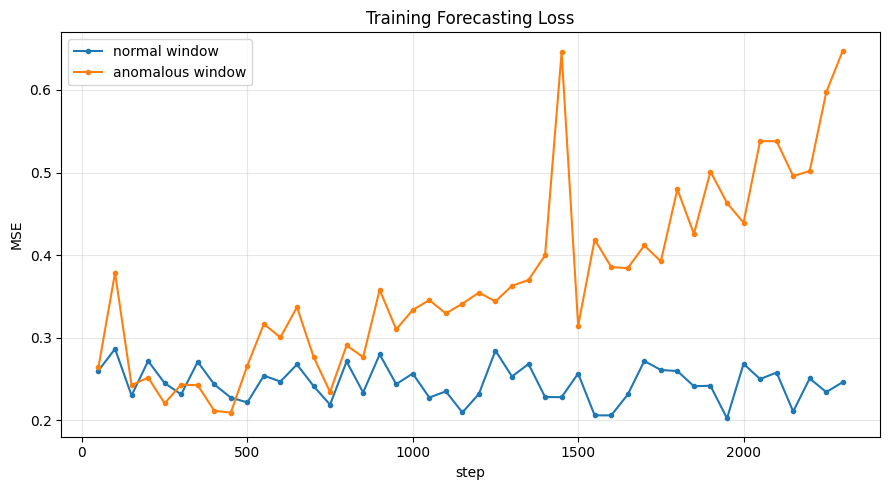

In [11]:
plt.figure(figsize=(9, 5))
plt.plot(tr_norm_x, tr_norm_y, marker=".", label="normal window")
plt.plot(tr_anom_x, tr_anom_y, marker=".", label="anomalous window")
plt.xlabel("step")
plt.ylabel("MSE")
plt.title("Training Forecasting Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

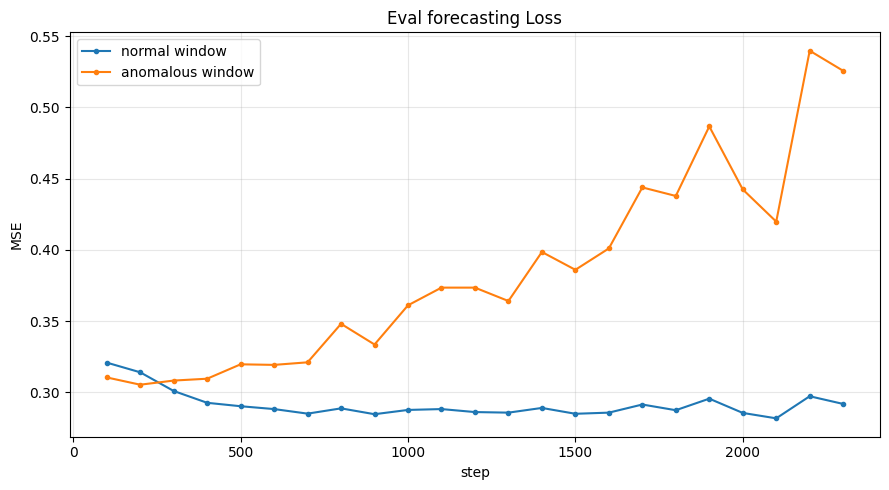

In [12]:
if ev_norm_x or ev_anom_x:
    plt.figure(figsize=(9, 5))
    plt.plot(ev_norm_x, ev_norm_y, marker=".", label="normal window")
    plt.plot(ev_anom_x, ev_anom_y, marker=".", label="anomalous window")
    plt.xlabel("step")
    plt.ylabel("MSE")
    plt.title("Eval forecasting Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No eval MSE keys found in log_history. "
          "Run with validation enabled (NO_VALIDATION=0) to populate eval_mse_* keys.")

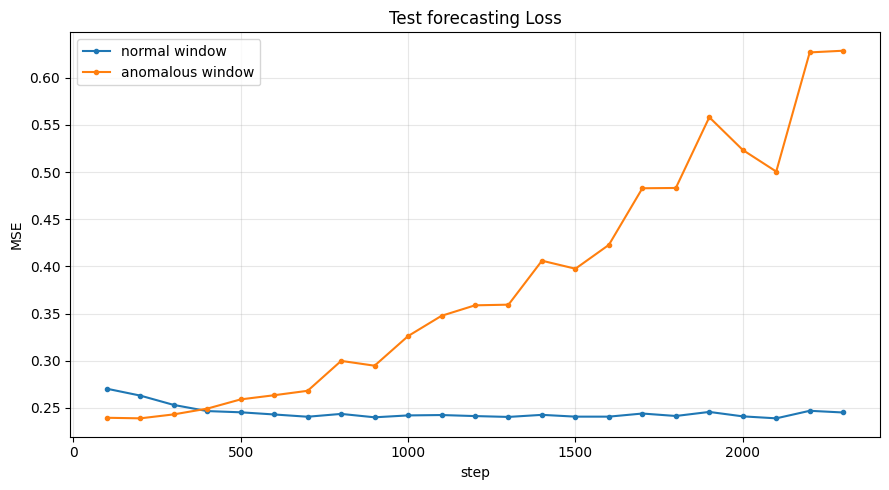

In [13]:
if te_norm_x or te_anom_x:
    plt.figure(figsize=(9, 5))
    plt.plot(te_norm_x, te_norm_y, marker=".", label="normal window")
    plt.plot(te_anom_x, te_anom_y, marker=".", label="anomalous window")
    plt.xlabel("step")
    plt.ylabel("MSE")
    plt.title("Test forecasting Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No test MSE keys found in log_history. "
          "Run with a test set (set TEST_DATA in run_finetune.sh / pass --test_data) "
          "to populate eval_test_mse_* keys.")